In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/01_fund_master.csv")

df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
df.shape

(40, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [6]:
df.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [7]:
df.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [10]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())
    print("-"*30)

fund_house
['SBI Mutual Fund' 'HDFC Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Kotak Mahindra MF' 'Axis Mutual Fund'
 'Aditya Birla Sun Life MF' 'UTI Mutual Fund' 'Mirae Asset MF'
 'DSP Mutual Fund']
------------------------------
scheme_name
['SBI Bluechip Fund - Regular Plan - Growth'
 'SBI Bluechip Fund - Direct Plan - Growth'
 'SBI Small Cap Fund - Regular Plan - Growth'
 'SBI Small Cap Fund - Direct Plan - Growth'
 'SBI Magnum Gilt Fund - Regular Plan - Growth'
 'HDFC Top 100 Fund - Regular Plan - Growth'
 'HDFC Top 100 Fund - Direct Plan - Growth'
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth'
 'HDFC Mid-Cap Opportunities Fund - Direct - Growth'
 'HDFC Short Term Debt Fund - Regular - Growth'
 'ICICI Pru Bluechip Fund - Regular - Growth'
 'ICICI Pru Bluechip Fund - Direct - Growth'
 'ICICI Pru Midcap Fund - Regular - Growth'
 'ICICI Pru Value Discovery Fund - Regular - Growth'
 'ICICI Pru Liquid Fund - Regular - Growth'
 'Nippon India Large Cap Fund - Regular -

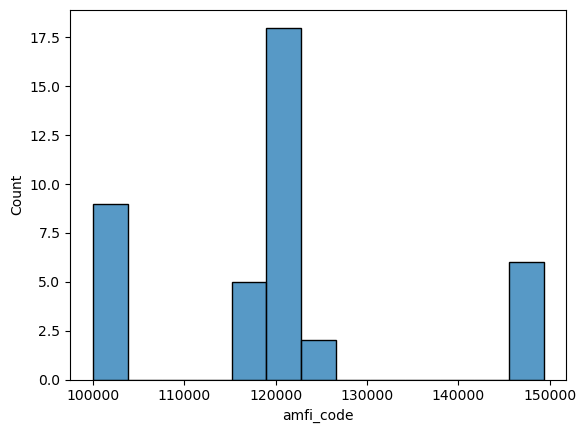

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.histplot(df[df.columns[0]])
plt.show()

In [13]:
df['scheme_name'].nunique()

40

In [14]:
df['scheme_name'].str.split().str[0].value_counts()

scheme_name
SBI       5
HDFC      5
ICICI     5
Nippon    5
Kotak     4
Axis      4
ABSL      3
UTI       3
Mirae     3
DSP       3
Name: count, dtype: int64

In [15]:
df['plan_type'] = df['scheme_name'].apply(lambda x: 'Direct' if 'Direct' in x else 'Regular')

df['plan_type'].value_counts()

plan_type
Regular    33
Direct      7
Name: count, dtype: int64

In [18]:
df['fund_house'] = df['scheme_name'].str.split().str[0]

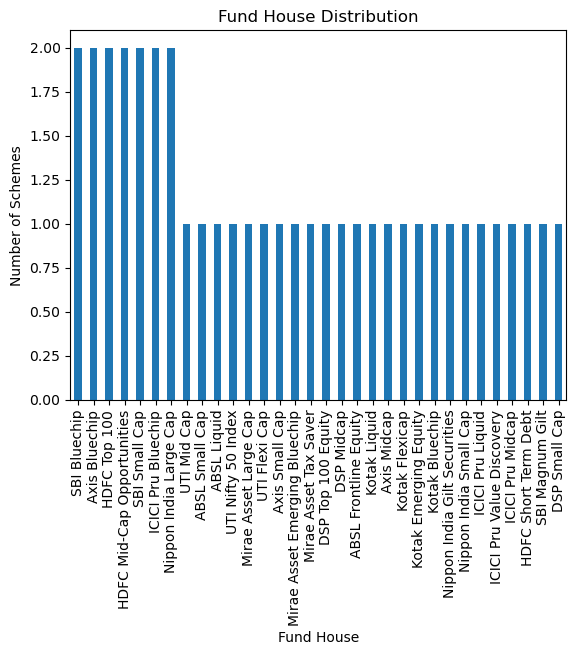

In [20]:
df['fund_house'].value_counts().plot(kind='bar')
plt.title("Fund House Distribution")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.show()

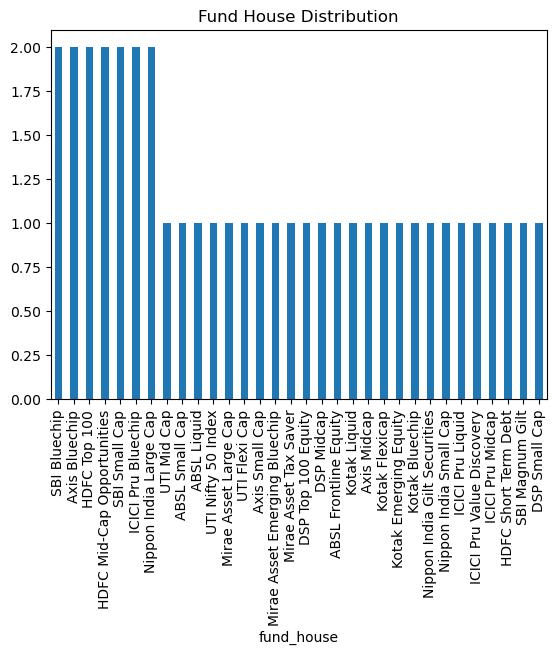

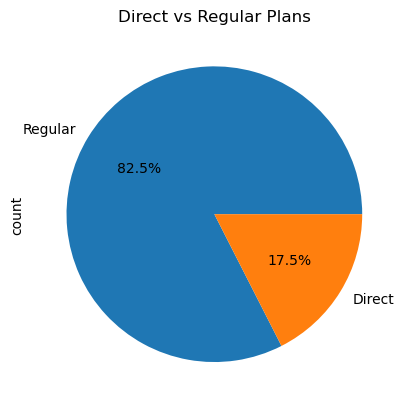

In [22]:
df['plan_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Direct vs Regular Plans")
plt.show()